<a href="https://colab.research.google.com/github/DevKevin42/Hello_Word/blob/main/FMNIST_Callbacks%2C_Data_Modules%2C_Data_Loaders_%5BPYTORCH_LIGHTNING_%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
# Detectar si se está ejecutando en Google Colab
if 'google.colab' in sys.modules:
    print("Ejecutando en Google Colab. Instalando dependencias requeridas...")
    !pip install -q lightning pynvml nvidia-ml-py
else:
    print("Ejecutando en entorno local.")


Ejecutando en entorno local.


In [2]:
import sys
# Detectar si se está ejecutando en Google Colab
if 'google.colab' in sys.modules:
    print("Ejecutando en Google Colab. Instalando dependencias requeridas...")
    !pip install -q lightning pynvml nvidia-ml-py
else:
    print("Ejecutando en entorno local.")


Ejecutando en entorno local.


# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-NN-Pytorch-callbacks-lighning-72d0d7e2ab024a6c9e5f3adfd4ee574b?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

# Redes Neuronales con el modelo PyTorch Lightning


In [3]:
 #%%capture
!pip install lightning

In [4]:
import os, torch
import torch.nn as nn
import torch.utils.data as data
import torchvision as tv
from torch.utils.data import random_split, DataLoader, Subset
from torchmetrics import Accuracy
import lightning as L

C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Está utilizando el dispositivo:", device)

Está utilizando el dispositivo: cpu


# Verificación de información de la GPU


In [6]:
import subprocess
import torch
if torch.cuda.is_available():
    try:
        print(subprocess.check_output("nvidia-smi", shell=True, text=True))
    except Exception:
        print("nvidia-smi no está disponible en el PATH del sistema.")
else:
    print("GPU no disponible en este entorno.")


GPU no disponible en este entorno.


In [7]:
import subprocess
import torch
if torch.cuda.is_available():
    try:
        print(subprocess.check_output("nvidia-smi -L", shell=True, text=True))
    except Exception:
        print("nvidia-smi no está disponible en el PATH del sistema.")
else:
    print("GPU no disponible en este entorno.")


GPU no disponible en este entorno.


In [8]:
num_gpus = 1 # num. gpus you want to use in this notebook

os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(x) for x in range(num_gpus))

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

CUDA_VISIBLE_DEVICES = 0


# Módulo de Datos PyTorch Lightning personalizado para el manejo del conjunto de datos


Este código define un módulo de datos personalizado `MyDataModule` usando PyTorch Lightning. Desglosemos lo que hace cada parte:

1. **Inicialización**:
    - El método `__init__` inicializa el módulo de datos con parámetros como `batch_size`, `transform`, `num_classes` e `input_shape`.
    - Configura una tubería (pipeline) de transformación utilizando `torchvision.transforms.Compose`. Esta tubería convierte los datos de entrada en tensores y luego los normaliza.

2. **Preparación de Datos**:
    - El método `prepare_data` es responsable de cualquier preparación única necesaria para los datos.
    - En este caso, descarga el conjunto de datos FashionMNIST si aún no se ha descargado y aplica la tubería de transformación definida anteriormente.

3. **Configuración de Datos (Setup)**:
    - El método `setup` prepara conjuntos de datos para entrenamiento, validación, prueba o predicción según la etapa especificada.
    - Para la etapa 'fit' (entrenamiento), divide el conjunto de datos de entrenamiento en conjuntos de entrenamiento y validación utilizando `random_split` de `torch.utils.data`.
    - Para la etapa 'test', prepara el conjunto de datos de prueba.
    - Para la etapa 'predict', configura un subconjunto del conjunto de datos de prueba que contiene los primeros 5 elementos, solo con fines de demostración.

4. **Cargadores de Datos (Data Loaders)**:
    - Los métodos `train_dataloader`, `val_dataloader`, `test_dataloader` y `predict_dataloader` devuelven instancias de PyTorch `DataLoader` para entrenamiento, validación, prueba y predicción, respectivamente.
    - Estos objetos `DataLoader` son responsables de agrupar por lotes, mezclar y cargar los datos.

5. **Instanciación del Módulo de Datos**:
    - Se crea una instancia de `MyDataModule` con un `batch_size` especificado de 32.
    - Se llama a `prepare_data` para asegurar que los datos estén preparados antes de la configuración.
    - Se llama a `setup` sin especificar una etapa, lo que significa que preparará los datos para todas las etapas (`'fit'`, `'test'` y `'predict'`).

Al utilizar este módulo de datos personalizado, puede organizar fácilmente su tubería de carga de datos, haciéndola más modular y reutilizable dentro de los bucles de entrenamiento de PyTorch Lightning.


In [9]:
class MyDataModule(L.LightningDataModule): #LDM
    def __init__(self, batch_size=64):
        super().__init__()
        self.batch_size = batch_size
        self.transform = tv.transforms.Compose([ #pipeline de computer vision
            tv.transforms.ToTensor()
           ,tv.transforms.Normalize((0.5,), (0.5,)) #normalize grayscale image to mean 0.5 and std 0.5
        ]) #pipeline for image processing

        self.num_classes = 10
        self.input_shape = 28*28 #784 pixels
    def prepare_data(self):
        # This method can be used for one-time data preparation
        # For example, downloading datasets or initializing data sources

        tv.datasets.FashionMNIST(root="./data", train=True, download=True, transform=self.transform)
        tv.datasets.FashionMNIST(root="./data", train=False, download=True, transform=self.transform)

    def setup(self, stage=None):
        # Data setup for training, validation, and testing
        if stage == 'fit' or stage is None:

            #Load training set (RAM)
            train_dataset = tv.datasets.FashionMNIST(root="./data", train=True, transform=self.transform)

            # Training validation split
            train_set_size = int(len(train_dataset) * 0.8) #80% train,
            valid_set_size = len(train_dataset) - train_set_size # 20%val
            seed = torch.Generator().manual_seed(42) # semilla aleatoria
            train_set, valid_set = random_split(train_dataset, [train_set_size, valid_set_size], generator=seed)

            self.train_dataset = train_set
            self.val_dataset = valid_set

        if stage == 'test' or stage is None:
            test_dataset = tv.datasets.FashionMNIST(root="./data", train=False, transform=self.transform) #test
            self.test_dataset = test_dataset

        if stage == 'predict' or stage is None:
            #select the first 5 elements of a dataloader just for this example
            test_dataset = tv.datasets.FashionMNIST(root="./data", train=False, transform=self.transform)
            self.predict_dataset = Subset(test_dataset, range(0, 5)) #just for predicting

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self):
        return DataLoader(self.predict_dataset, batch_size=self.batch_size, shuffle=False)

dm = MyDataModule(batch_size=32)
# To access the x_dataloader we need to call prepare_data and setup.
dm.prepare_data()
#dm.setup(stage="fit")
dm.setup()

#Visualización del conjunto de datos FMNIST


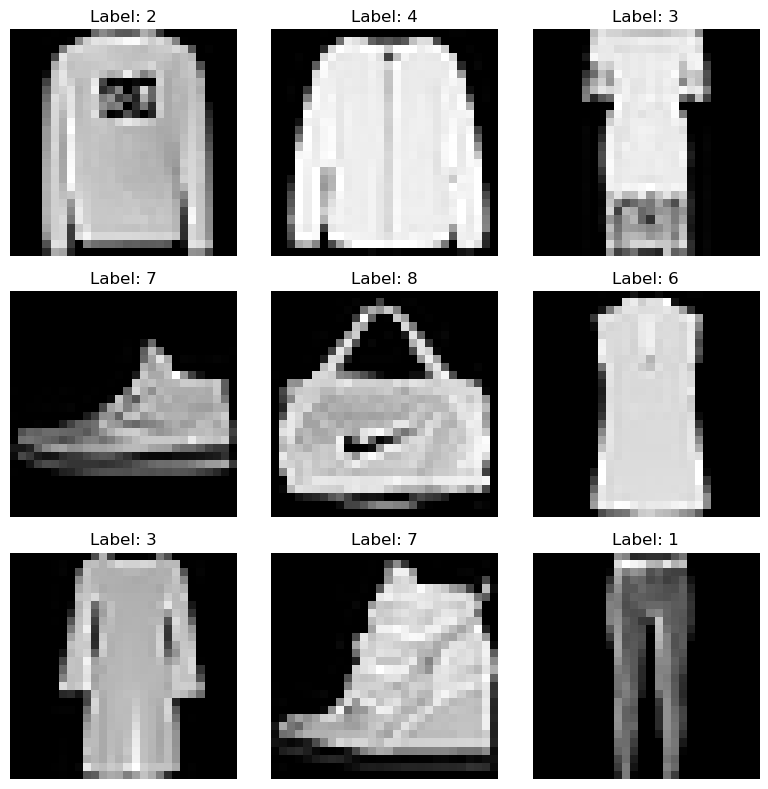

In [10]:
import matplotlib.pyplot as plt
import random

# Create a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

# Randomly select 9 images from the training dataset
random_indices = random.sample(range(len(dm.train_dataset)), 9)

# Loop through each subplot and plot an image with its label
for i, ax in enumerate(axes.flat):
    # Get image and label from the dataset
    img, labelidx = dm.train_dataset[random_indices[i]]
    img = img.view(28, 28, 1)

    # Plot the image
    ax.imshow(img.squeeze(), cmap='gray')

    # Print the label
    ax.set_title(f'Label: {labelidx}')

    # Remove axes
    ax.axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



Let's dive deeper into the modified code to visualize a 3x3 grid of random images from the FashionMNIST dataset:

1. **Importing Libraries**: We start by importing the necessary libraries, including `matplotlib.pyplot` for visualization and `random` for generating random indices.

2. **Creating Subplots**:
   - We use `plt.subplots(3, 3, figsize=(8, 8))` to create a 3x3 grid of subplots with a specific size (8x8 inches).
   - This function returns a figure object (`fig`) and an array of axes objects (`axes`), which represent the individual subplots.

3. **Randomly Selecting Images**:
   - We generate 9 random indices using `random.sample(range(len(dm.train_dataset)), 9)`.
   - These indices are used to select 9 random images from the training dataset.
   - `len(dm.train_dataset)` returns the total number of images in the training dataset, and `random.sample()` selects 9 unique indices from this range.

4. **Plotting Images and Labels**:
   - We iterate over each subplot using `enumerate(axes.flat)`.
   - For each subplot, we retrieve the corresponding image and label from the dataset using the randomly selected indices.
   - The image is reshaped to match the dimensions expected by `imshow()` using `img.view(28, 28, 1)`.
   - We plot the image using `ax.imshow()` and specify `cmap='gray'` to display it in grayscale.
   - The label is printed as the title of the subplot using `ax.set_title(f'Label: {labelidx}')`.

5. **Removing Axes**:
   - We remove the axes from each subplot using `ax.axis('off')` to clean up the visualization.

6. **Adjusting Layout**:
   - We call `plt.tight_layout()` to adjust the layout of the subplots and prevent overlap between them.

7. **Displaying the Plot**:
   - Finally, we use `plt.show()` to display the plot containing the 3x3 grid of images.


#Understanding a PyTorch Lightning Model


This code defines a PyTorch Lightning module named `Mymodel`. Let's break down what each part does:

1. **Initialization**:
   - The `__init__` method initializes the model with parameters such as `input_shape`, `num_classes`, and `hidden_units`.
   - It defines the layers of the model using a list `layers`. The layers include a flattening layer, a series of fully connected (linear) layers with batch normalization and ReLU activation, and a final linear layer for classification.
   - It sets up the loss function (`nn.CrossEntropyLoss()`) and accuracy metric (`Accuracy`).

2. **Forward Pass**:
   - The `forward` method defines the forward pass of the model, which applies the defined layers to the input data.

3. **Optimizer Configuration**:
   - The `configure_optimizers` method specifies the optimizer used for training, in this case, Adam optimizer with a learning rate of 0.001.

4. **Training Step**:
   - The `training_step` method defines the operations performed during a single training step.
   - It computes the logits (raw predictions) using the forward pass, calculates the loss and accuracy, and logs them for monitoring.

5. **Validation and Test Steps**:
   - Similar to the training step, the `validation_step` and `test_step` methods define the operations during validation and testing.
   - They compute logits, calculate loss and accuracy, and log these metrics.

6. **Prediction Step**:
   - The `predict_step` method is optional and defined here for inference purposes. It performs the forward pass without computing loss or accuracy and returns the raw predictions.

7. **Instantiation**:
   - The model is instantiated with the specified `input_shape`, `num_classes`, and `hidden_units`.

Overall, this code provides a structured and modular way to define a neural network model for classification tasks using PyTorch Lightning, along with functionalities for training, validation, testing, and inference.

In [11]:
class Mymodel(L.LightningModule):
    def __init__(self, input_shape, num_classes, hidden_units, lambda_L2=0.0):
        super().__init__()

        #self.classifier = nn.Sequential(
        #    nn.Flatten(),
        #    nn.Linear(input_shape, 16),
        #    nn.ReLU(),
        #    nn.Linear(16, num_classes)
        #)
        self.hidden_units = hidden_units  # Store the list of hidden units
        layers = []
        layers.append(nn.Flatten()) # entrada layer
        # Add hidden layers with ReLU activation
        for units in hidden_units: #hidden layers
            layers.append(nn.Linear(input_shape, units)) #logits
            layers.append(nn.BatchNorm1d(units))
            layers.append(nn.LeakyReLU(negative_slope=0.01))
            input_shape = units
        layers.append(nn.Linear(input_shape, num_classes))# salida layer, logits
        self.classifier = nn.Sequential(*layers) # here the output are logits

        self.lambda_L2 = lambda_L2  # L2 regularization strength
        self.loss = nn.CrossEntropyLoss() #Multiclass
        self.accuracy = Accuracy(task="multiclass",  num_classes=num_classes)
    #for inference
    def forward(self, x):
        return self.classifier(x) #logits

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001, weight_decay=self.lambda_L2)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs) #this calls forward. Do not use .forward
        loss = self.loss(logits, labels) # here is the softmax function!

        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, labels)

        self.log('train_loss', loss, on_step=True, on_epoch=True, logger=True)
        self.log('train_acc', acc, on_step=True, on_epoch=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs) #this calls forward
        loss = self.loss(logits, labels)

        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, labels)
        self.log('val_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('val_acc', acc, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs) #this calls forward
        loss = self.loss(logits, labels)

        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, labels)
        self.log('test_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('test_acc', acc, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss
    def predict_step(self, batch): #not necessary if dataloader with custom collate for prediction available (see OPTION 3 at the end of the notebook)
        # this calls forward for the inputs only
        inputs, labels = batch
        return self(inputs) #return logits, this calls forward

hidden_units = [32, 64, 16]  # Example hidden units list MLP, 3 hidden layers.
lambda_L2 = 0.0 #regularizer
model = Mymodel(input_shape=dm.input_shape, #28*28
                num_classes=dm.num_classes, #10
                hidden_units=hidden_units,
                lambda_L2=lambda_L2)#regularization L2




##Visualización del modelo


A model visualization provides valuable insights into the structure and complexity of the neural network model, helping you understand its architecture and assess its capabilities.


The first way to visualize a model is by simply printing the `model` object. In PyTorch Lightning, the `model` is typically an instance of a LightningModule, which encapsulates the neural network model along with training and evaluation logic. By printing the `model`, you'll see its structure and possibly any attributes it contains.

In [12]:
print(model) #hidden_units = [32 64 16]

Mymodel(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=64, out_features=16, bias=True)
    (8): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.01)
    (10): Linear(in_features=16, out_features=10, bias=True)
  )
  (loss): CrossEntropyLoss()
  (accuracy): MulticlassAccuracy()
)


Another way to visualize the model is using the `torchsummary` library

In [13]:
from torchsummary import summary
# Use torchsummary to print the summary
summary(model.to(device), input_size=(1, 28, 28))  # input_size=(channels, height, width), channels=1 grayscale, channels=3 RGB color

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 32]          25,120
       BatchNorm1d-3                   [-1, 32]              64
         LeakyReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 64]           2,112
       BatchNorm1d-6                   [-1, 64]             128
         LeakyReLU-7                   [-1, 64]               0
            Linear-8                   [-1, 16]           1,040
       BatchNorm1d-9                   [-1, 16]              32
        LeakyReLU-10                   [-1, 16]               0
           Linear-11                   [-1, 10]             170
Total params: 28,666
Trainable params: 28,666
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

Let's break down the code:


```python
from torchsummary import summary
```

This line imports the `summary` function from the `torchsummary` library. This function is used to print a summary of the PyTorch model's architecture, including information about the layers, output shapes, and the total number of parameters.


```python
summary(model, input_size=(1, 28, 28))
```

Here, the `summary` function is called with two arguments:
- `model`: This is the PyTorch model. It represents the underlying neural network architecture.
- `input_size=(1, 28, 28)`: This specifies the input size expected by the model. The input size is defined as a tuple `(channels, height, width)`, where `1` indicates the number of channels (grayscale image), and `28` is the height and width of the input image from FMNIST dataset.

The `summary` function will then generate and print a summary of the model's architecture, which includes details such as:
- Layer names
- Output shapes of each layer
- Number of parameters (trainable and non-trainable)
- Total number of parameters in the model

# Understanding Callbacks in PyTorch Lightning for Enhanced Training Control

A callback in programming is a function or a piece of code that is passed as an argument to another function or method. It allows you to customize or extend the behavior of the function or method without modifying its actual code. In the context of machine learning frameworks like PyTorch Lightning, a callback is a piece of code that is executed at specific points during the training process, such as after each epoch or after a certain metric threshold is reached.

Concretely, we use the following callbacks

In [14]:
# Inicializar Callbacks
early_stop_callback = L.pytorch.callbacks.EarlyStopping(monitor="val_loss",
                                                        mode="min",
                                                        patience=3)
checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(save_top_k=5,
                                                          save_last=True,
                                                          monitor="val_loss",
                                                          mode='min')


Ahora, desglosemos el fragmento de código:

1. **Callback EarlyStopping**:
   - `early_stop_callback` se inicializa con una instancia del callback `EarlyStopping`.
   - Este callback monitorea la pérdida de validación (`monitor="val_loss"`) e intenta minimizarla (`mode="min"`).
   - Espera un número de épocas de paciencia (`patience`, en este caso, 3 épocas) antes de considerar detener el entrenamiento si la cantidad monitoreada (pérdida de validación) no mejora.

2. **Callback ModelCheckpoint**:
   - `checkpoint_callback` se inicializa con una instancia del callback `ModelCheckpoint`.
   - Este callback guarda los puntos de control (checkpoints) del modelo durante el entrenamiento en el disco.
   - Guarda los 5 mejores modelos basados en la pérdida de validación (`save_top_k=5`).
   - Adicionalmente, guarda el último modelo (`save_last=True`) después de que se completa el entrenamiento.
   - Al igual que `EarlyStopping`, monitorea la pérdida de validación (`monitor="val_loss"`) e intenta minimizarla (`mode="min"`).

En resumen, el código proporcionado inicializa dos callbacks: `EarlyStopping` y `ModelCheckpoint`. Estos callbacks brindan funcionalidad adicional al proceso de entrenamiento, como detener el entrenamiento temprano si el rendimiento del modelo deja de mejorar (`EarlyStopping`) y guardar los puntos de control del modelo para su uso posterior (`ModelCheckpoint`). Estos callbacks mejoran la flexibilidad y funcionalidad del bucle de entrenamiento, lo que facilita la gestión y el seguimiento del proceso de entrenamiento de forma eficaz.


#Configuración del Entrenador PyTorch Lightning


Este fragmento de código demuestra cómo instanciar un objeto PyTorch Lightning Trainer con aceleración por GPU si hay un dispositivo GPU compatible con CUDA disponible, y sin ella si no es así. Esta flexibilidad permite que el código se adapte sin problemas a diferentes configuraciones de hardware, optimizando el rendimiento en función de los recursos disponibles.


In [15]:
trainer = None
print('*'*80)
print("Está usando:", device.type)
print('*'*80)
trainer = L.Trainer(max_epochs=5 if device.type != 'cuda' else 50,
                    callbacks=[early_stop_callback, checkpoint_callback],
                    accelerator="gpu" if device.type == "cuda" else "cpu",
                    devices=1)#only works on script mode for devices > 1


********************************************************************************
Está usando: cpu
********************************************************************************


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Explicación:

1. **Verificación de disponibilidad del dispositivo**:
   - El código verifica si la variable `device` está establecida en `"cuda"`, lo que indica la presencia de un dispositivo GPU habilitado para CUDA.
   - Si `device == "cuda"`, significa que el código utilizará la aceleración por GPU para el entrenamiento.

2. **Instanciación del objeto Trainer**:
   - Si hay un dispositivo GPU disponible (`device == "cuda"`), el objeto Trainer se instancia con la aceleración por GPU habilitada.
     - `max_epochs=50` especifica que el entrenamiento se ejecutará durante un máximo de 50 épocas.
     - `callbacks=[early_stop_callback, checkpoint_callback]` especifica una lista de callbacks que se utilizarán durante el entrenamiento, lo que incluye la detención temprana y el guardado de checkpoints del modelo.
     - `accelerator="gpu"` indica que se utilizará la aceleración por GPU.
     - `devices=1` especifica la cantidad de dispositivos GPU que se utilizarán. Aquí se establece en 1, lo que indica que solo se usará una GPU para el entrenamiento.
   - Si no hay un dispositivo GPU disponible (`device != "cuda"`), el objeto Trainer se instancia sin aceleración por GPU.
     - Los parámetros siguen siendo los mismos que los anteriores, pero sin especificar los parámetros `accelerator` o `devices`. Por defecto, si no se especifica la aceleración por GPU, PyTorch Lightning utilizará la CPU para el entrenamiento.


#Entrenemos el modelo


Este fragmento de código ilustra el uso del método `fit()` para entrenar un modelo PyTorch Lightning (`model`) utilizando datos proporcionados por un LightningDataModule (`dm`). Especifica la ruta para guardar los checkpoints del modelo durante el entrenamiento (`ckpt_path='last'`) para garantizar que el progreso del modelo entrenado se guarde para su uso o evaluación futura.


In [16]:
trainer.fit(model, dm,
            #checkpoint_callback.best_model_path  or 'best'.
            #use last if it is the first time you train.
            ckpt_path='last'
            )

C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\lightning\pytorch\trainer\connectors\checkpoint_connector.py:190: .fit(ckpt_path="last") is set, but there is no last checkpoint available. No checkpoint will be loaded. HINT: Set `ModelCheckpoint(..., save_last=True)`.


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ classifier │ Sequential         │ 28.7 K │ train │     0 │
│ 1 │ loss       │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 28.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 28.7 K                                                                                               
Total estimated model params size (MB): 0.115                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.
py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of
the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.
py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value 
of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=5` reached.


### Explicación:

- **Método trainer.fit()**:
  - `trainer.fit()` es un método proporcionado por el objeto PyTorch Lightning Trainer, que es responsable de entrenar el modelo.
  - Toma dos argumentos principales:
    - El primer argumento (`model`) es la instancia de LightningModule que representa el modelo de red neuronal a entrenar.
    - El segundo argumento (`dm`) es la instancia de LightningDataModule que proporciona los cargadores de datos para entrenamiento, validación y prueba.
  - En este caso, `model` es el objeto del modelo a entrenar y `dm` es el objeto del módulo de datos que contiene los cargadores de datos necesarios para el entrenamiento.

- **Ruta del Punto de Control (`ckpt_path`)**:
  - El parámetro `ckpt_path` especifica la ruta para cargar o guardar los checkpoints del modelo durante el entrenamiento.
  - En este código, `ckpt_path='last'` indica que el Entrenador guardará el último checkpoint del modelo después de cada época. Este checkpoint se usará para reanudar el entrenamiento si se interrumpe o para evaluar el modelo después de entrenar.
  - Alternativamente, la línea comentada (`#checkpoint_callback.best_model_path o 'best'`) sugiere una opción para especificar la ruta del mejor checkpoint del modelo basado en un callback de checkpoint proporcionado (`checkpoint_callback`). Supone que el atributo `best_model_path` del `checkpoint_callback` contiene la ruta al mejor checkpoint del modelo guardado durante el entrenamiento. Si el atributo no está disponible o si no se utiliza el callback, por defecto es `'best'`.


## Evaluación del modelo en el conjunto de validación


Este fragmento de código demuestra cómo usar el método `validate()` del objeto PyTorch Lightning Trainer para evaluar un modelo entrenado (`model`) en un conjunto de datos de validación. Al especificar los cargadores de datos para la validación y la ruta al checkpoint del modelo, el Entrenador asegura que la evaluación se realice utilizando el mejor modelo obtenido durante el entrenamiento.


In [17]:
trainer.validate(model, dataloaders=dm.val_dataloader(), ckpt_path='best')

Restoring states from the checkpoint path at d:\OneDrive\Estudios\MAESTRIA CIENCIA DE DATOS\Machine Learning\Talleres\Talleres\lightning_logs\version_4\checkpoints\epoch=4-step=7500.ckpt


Loaded model weights from the checkpoint at d:\OneDrive\Estudios\MAESTRIA CIENCIA DE DATOS\Machine Learning\Talleres\Talleres\lightning_logs\version_4\checkpoints\epoch=4-step=7500.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_acc_epoch       │    0.8786666393280029     │
│      val_loss_epoch       │    0.33758482336997986    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss_epoch': 0.33758482336997986, 'val_acc_epoch': 0.8786666393280029}]

### Explicación:

- **Método trainer.validate()**:
  - `trainer.validate()` es un método proporcionado por el objeto PyTorch Lightning Trainer, que se utiliza para la validación del modelo.
  - Toma varios argumentos:
    - El primer argumento (`model`) es la instancia de LightningModule que representa el modelo de red neuronal a evaluar.
    - El argumento `dataloaders` especifica los cargadores de datos que se utilizarán para la validación. En este caso, se proporciona como `dm.val_dataloader()`, que devuelve el cargador de datos de validación del LightningDataModule (`dm`) dado.
    - El parámetro `ckpt_path` especifica la ruta para cargar el checkpoint del modelo antes de la validación. En este fragmento de código, `ckpt_path='best'` indica que el Entrenador cargará el mejor checkpoint del modelo guardado durante el entrenamiento para la validación. Esto asegura que se use el modelo con mejor rendimiento para la evaluación.


# Visualización del proceso de entrenamiento


El comando `%tensorboard --logdir lightning_logs` inicia TensorBoard y le indica que cargue los archivos de registro desde el directorio `lightning_logs`. Luego, TensorBoard muestra visualizaciones del progreso del entrenamiento, incluidas métricas, curvas de pérdida, histogramas de parámetros del modelo y más, lo que le permite analizar y monitorear el rendimiento de sus modelos de PyTorch Lightning de manera interactiva.

### Explicación:
- El comando `%load_ext tensorboard` es un comando mágico de Jupyter Notebook utilizado para cargar la extensión TensorBoard dentro del entorno del notebook.
- **Comando mágico `%tensorboard`**:
  - El comando `%tensorboard` es un comando mágico que le permite iniciar TensorBoard directamente dentro del entorno de Jupyter Notebook.
  - Este comando se usa típicamente cuando desea visualizar registros y métricas generados durante el entrenamiento de modelos de aprendizaje automático.

- **Argumento `--logdir`**:
  - El argumento `--logdir` especifica el directorio donde se almacenan los archivos de registro. En este caso, está configurado como `lightning_logs`.
  - PyTorch Lightning registra automáticamente varias métricas, como pérdida, precisión, etc., durante las etapas de entrenamiento, validación y prueba. Estos registros se guardan en el directorio `lightning_logs` de forma predeterminada.






In [18]:
# Cargar la extensión de TensorBoard para notebooks
#%load_ext tensorboard
# No funciona con entornos de ejecución locales ()
%reload_ext tensorboard

In [19]:
%tensorboard --logdir "/content/lightning_logs"


ERROR: Could not find `tensorboard`. Please ensure that your PATH
contains an executable `tensorboard` program, or explicitly specify
the path to a TensorBoard binary by setting the `TENSORBOARD_BINARY`
environment variable.

# Probar el modelo


Este fragmento de código demuestra cómo utilizar el método `test()` del objeto PyTorch Lightning Trainer para evaluar un modelo entrenado (`model`) en un conjunto de datos de prueba. Al especificar el o los cargadores de datos para las pruebas y la ruta al checkpoint del modelo, el Entrenador asegura que la evaluación se realice utilizando el mejor modelo obtenido durante el entrenamiento.


In [20]:
# Probar el modelo
#dm.setup(stage='test')
trainer.test(model, dataloaders=dm.test_dataloader(), ckpt_path='best')

Restoring states from the checkpoint path at d:\OneDrive\Estudios\MAESTRIA CIENCIA DE DATOS\Machine Learning\Talleres\Talleres\lightning_logs\version_4\checkpoints\epoch=4-step=7500.ckpt


Loaded model weights from the checkpoint at d:\OneDrive\Estudios\MAESTRIA CIENCIA DE DATOS\Machine Learning\Talleres\Talleres\lightning_logs\version_4\checkpoints\epoch=4-step=7500.ckpt


C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │    0.8745999932289124     │
│      test_loss_epoch      │    0.3598911166191101     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.3598911166191101, 'test_acc_epoch': 0.8745999932289124}]

### Explicación:

- **Método `trainer.test()`**:
  - `trainer.test()` es un método proporcionado por el objeto PyTorch Lightning Trainer, utilizado para la evaluación del modelo en un conjunto de datos de prueba.
  - Toma varios argumentos:
    - El primer argumento (`model`) es la instancia de LightningModule que representa el modelo de red neuronal a evaluar.
    - El argumento `dataloaders` especifica los cargadores de datos que se utilizarán para las pruebas. En este caso, se proporciona como `dm.test_dataloader()`, que devuelve el cargador de datos de prueba del LightningDataModule (`dm`) dado.
    - El parámetro `ckpt_path` especifica la ruta para cargar el checkpoint del modelo antes de las pruebas. En este fragmento de código, `ckpt_path='best'` indica que el Entrenador cargará el mejor checkpoint del modelo guardado durante el entrenamiento para realizar las pruebas. Esto asegura que se use el modelo con mejor rendimiento para la evaluación.



# Realizar predicciones: etapa de Inferencia


La inferencia, en el contexto del aprendizaje profundo, se refiere al proceso de utilizar un modelo de red neuronal entrenado para realizar predicciones u obtener conclusiones a partir de datos nuevos y no vistos. Durante la inferencia, los datos de entrada se alimentan al modelo entrenado, que los procesa a través de sus capas para producir predicciones de salida. Estas predicciones pueden incluir etiquetas de clase, valores de regresión o cualquier otro resultado deseado según la tarea.

En PyTorch Lightning, hay dos etapas distintas en las que se evalúa un modelo entrenado: la etapa de **predicción (inferencia)** y la etapa de **prueba (test)**. Aquí hay una aclaración de la diferencia entre estas dos etapas:

1. **Etapa de Predicción (Inferencia)**:
   - **Propósito**: Se centra principalmente en realizar predicciones o inferencias sobre datos nuevos y no vistos.
   - **Uso**: Se utiliza cuando desea aplicar el modelo entrenado a nuevos datos para obtener predicciones o salidas.
   - **Entrada**: Por lo general, se proporcionan datos de entrada al modelo para la inferencia y se obtienen las predicciones de salida del modelo.
   - **Escenario**: Esta etapa se usa comúnmente en aplicaciones del mundo real donde el modelo entrenado se implementa para realizar predicciones sobre entradas de usuarios, imágenes, texto o cualquier otro dato.
   - **Flexibilidad**: PyTorch Lightning brinda flexibilidad para realizar inferencias, lo que le permite anular el método `predict_step` en su LightningModule para personalizar el proceso de inferencia.

2. **Etapa de Prueba (Test)**:
   - **Propósito**: Se centra en evaluar el rendimiento del modelo entrenado en un conjunto de datos de prueba independiente.
   - **Uso**: Se utiliza para evaluar la capacidad de generalización y el rendimiento general del modelo en datos no vistos.
   - **Entrada**: Los datos de entrada del conjunto de datos de prueba se proporcionan al modelo y las predicciones se comparan con las etiquetas reales (ground-truth) para calcular métricas de evaluación como precisión, recall, F1-score, etc.
   - **Escenario**: Esta etapa se usa comúnmente durante el desarrollo y la experimentación del modelo para validar su rendimiento antes de su despliegue en producción.
   - **Evaluación**: PyTorch Lightning proporciona métodos convenientes como `trainer.test()` para automatizar el proceso de evaluación durante la etapa de prueba. Estos métodos manejan el paso hacia adelante, calculan las métricas y proporcionan los resultados de la evaluación.

En PyTorch Lightning, existen múltiples enfoques para realizar inferencias, cada uno con sus propias ventajas y consideraciones. Estos enfoques van desde aprovechar las capacidades integradas de PyTorch Lightning, como anular el método `predict_step`, hasta métodos más manuales como llamar directamente al método `forward` del modelo. Cada enfoque ofrece flexibilidad y compensaciones en términos de simplicidad, eficiencia y personalización.


Aquí presentamos 3 opciones para realizar predicciones. La **Opción 1** es el método preferido, ya que aprovecha las capacidades integradas de PyTorch Lightning y es más ágil. Las opciones 1 y 2 están comentadas en el código.

### Opción 1:
Esta opción demuestra el método preferido para realizar inferencias en PyTorch Lightning anulando el método `predict_step`. Así es como funciona:

- **Anulación de Predict Step**:
  - El método `predict_step` se anula dentro del LightningModule (consulte el modelo de red neuronal arriba).
  - En este método, se llama al método `forward` directamente. Este es el mismo método utilizado durante el entrenamiento y la validación, pero adaptado específicamente para la inferencia.
  - No es necesario llamar a `eval()` ni utilizar `torch.no_grad()` explícitamente, ya que PyTorch Lightning maneja esto internamente.
  
- **Proceso de Inferencia**:
  - El LightningDataModule se configura para inferencia utilizando `dm.setup(stage='predict')`.
  - Se llama al método `predict` del Trainer, pasando el modelo y el cargador de datos para la inferencia.
  - Se obtienen los logits predichos y se aplica softmax para obtener probabilidades.
  - Las etiquetas predichas se infieren a partir de las probabilidades.
  - Se extraen las etiquetas de verdad de campo (ground-truth) para comparar.
  - Finalmente, se visualizan las probabilidades.

### Opción 2 (comentada en el código a continuación):
Esta opción demuestra un enfoque alternativo en el que se define un cargador de datos personalizado que solo devuelve entradas para la inferencia:

- **Cargador de datos personalizado**:
  - Define una función de colación personalizada (`custom_collate`) para extraer solo las entradas del lote.
  - El cargador de datos se configura con esta función de colación personalizada.
  
- **Proceso de Inferencia**:
  - Se llama al método `predict` del Trainer, pasando solo el cargador de datos (ya que ahora solo devuelve entradas).
  - Se obtienen los logits predichos.
  
- **Sin paso Predict Step**:
  - La Opción 2 no requiere un método `predict_step` como la opción 1. En su lugar, se basa en cargadores de datos personalizados.

### Opción 3:
Esta opción demuestra llamar directamente al método `forward` para inferencia a través de `model(inputs)`:

- **Uso de `forward`**:
  - Llama directamente al método `forward` del modelo.
  - Debe manejar manualmente la evaluación del modelo (`eval()`) y la supresión del seguimiento de gradientes (`torch.no_grad()`).

- **Proceso de Inferencia**:
  - El modelo se pone en modo de evaluación usando `model.eval()`.
  - La inferencia se realiza directamente llamando al método `forward` con las entradas.
  - El seguimiento del gradiente se deshabilita dentro del contexto `torch.no_grad()`.
  - Se obtienen los logits predichos.
  
- **Sin paso Predict Step**:
  - La Opción 3 no requiere un método `predict_step` como la opción 1. En su lugar, se basa en llamadas directas a `forward` para la inferencia a través de `model(inputs)`. Tenga en cuenta que al llamar a model(inputs), está invocando implícitamente el método forward del modelo.


Restoring states from the checkpoint path at d:\OneDrive\Estudios\MAESTRIA CIENCIA DE DATOS\Machine Learning\Talleres\Talleres\lightning_logs\version_4\checkpoints\epoch=4-step=7500.ckpt


Loaded model weights from the checkpoint at d:\OneDrive\Estudios\MAESTRIA CIENCIA DE DATOS\Machine Learning\Talleres\Talleres\lightning_logs\version_4\checkpoints\epoch=4-step=7500.ckpt


C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


pred_logits[0].shape is torch.Size([5, 10])
predicted_probs_list is [tensor([[1.0159e-04, 5.5658e-07, 6.7824e-05, 2.6451e-05, 5.0018e-05, 3.1391e-02,
         6.2184e-05, 2.2320e-01, 3.2084e-04, 7.4478e-01],
        [8.6521e-06, 5.8212e-09, 9.8552e-01, 1.9717e-06, 1.1127e-02, 9.6343e-07,
         3.3267e-03, 7.4577e-06, 1.7446e-07, 6.2729e-06],
        [6.8984e-05, 9.9991e-01, 2.0743e-07, 9.8997e-06, 1.4156e-06, 4.7211e-07,
         1.2375e-06, 7.8749e-08, 5.4636e-06, 1.1988e-07],
        [1.4045e-04, 9.9951e-01, 1.2282e-05, 2.3860e-04, 2.6339e-05, 2.7225e-05,
         3.2374e-05, 6.4121e-08, 7.5569e-06, 1.5870e-06],
        [4.3642e-02, 1.6561e-05, 7.8152e-03, 2.7556e-03, 1.1191e-02, 9.5559e-05,
         9.3393e-01, 7.4292e-06, 5.4453e-04, 3.9274e-06]])]
predicted_labels_list is [tensor([9, 2, 1, 1, 6])]
labels_list is [9, 2, 1, 1, 6]


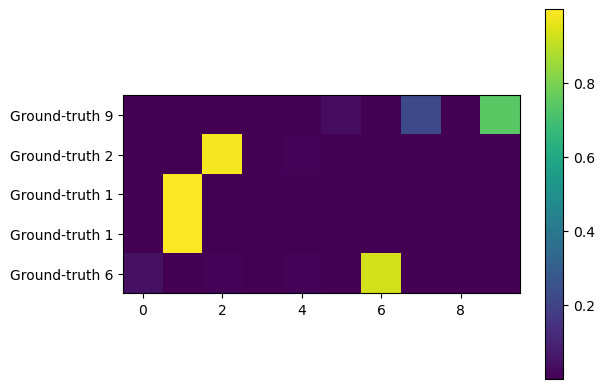

In [21]:
#OPTION 1 (PREFERRED). overrides predict_step that calls forward

#this calls the overridden predict_step which in turn calls forward.
# no need to call eval() or no_grad()

#dm.setup(stage='predict')
pred_logits = trainer.predict(model, dataloaders=dm.predict_dataloader(), ckpt_path='best')
print("pred_logits[0].shape is", pred_logits[0].shape)

# Assuming 'pred_logits' is a list of tensors, e.g., [tensor1, tensor2, tensor3, ...]
# Get the predicted probs for each example in the list using softmax
predicted_probs_list = [torch.softmax(logits, dim=1) for logits in pred_logits]
print("predicted_probs_list is", predicted_probs_list)
# 'predicted_labels_list' now contains the inferred class labels for each example
predicted_labels_list = [torch.argmax(probs, dim=1) for probs in predicted_probs_list]
print("predicted_labels_list is", predicted_labels_list)
# Assuming your DataLoader returns (inputs, labels) for each batch
# Use list comprehension to extract labels for all examples in the DataLoader
labels_list = [labels for _, labels in [batch for batch in dm.predict_dataloader()]]
labels_list = labels_list[0].tolist() # because the previous step return a torch tensor inside a list. The 0th element is the torch tensor
# 'labels_list' now contains the labels for all examples in the DataLoader

print("labels_list is", labels_list)

#visualize the probabilities
# Stack the list of tensors into a 2D tensor
stacked_tensor = torch.stack(predicted_probs_list, dim=0).view(5,10)
# Reshape the 2D tensor into a 2D numpy array
numpy_array = stacked_tensor.numpy()
# Visualize the 2D numpy array as an image
plt.imshow(numpy_array, cmap='viridis')  # You can choose a different colormap
# Convert the tensors in labels_list to strings
string_labels = [str(label) for label in labels_list]
prefixed_strings = ["Ground-truth " + string for string in string_labels]
# Set the y tick labels to the string values
plt.yticks(range(len(string_labels)), prefixed_strings)
plt.colorbar()
plt.show()


#OPTION 2 no predict_step needed. Need to define a dataloader that returns only the inputs
#def custom_collate(batch):
#    # Extract only the inputs and return them as a list
#    list_inputs = [item[0] for item in batch]
#    stacked_inputs = torch.stack(list_inputs, dim=0)
#    return stacked_inputs

#imgx, labelx = test_dataset[0]
#predict_dataset = data.TensorDataset(imgx)
#predict_dataloader = data.DataLoader(predict_dataset, batch_size=1, collate_fn=custom_collate)
#print(predict_dataloader.dataset[0])
#pred_logits = trainer.predict(dataloaders=predict_dataloader)
#print((pred_logits[0]))


# OPTION 3, calling directly forward.
#When using forward, you are responsible to call eval() and use the no_grad() context manager.
#model.eval()
#with torch.no_grad():
#    inputs, lab = test_dataloader.dataset[0]
#    pred = model(inputs) #this calls forward
#    print(pred)



#Visualización del modelo con Tensorboard


In [22]:
from torch.utils.tensorboard import SummaryWriter
X_probe = torch.randn(5,28,28) #just a (batch,width, height) probe input
writer = SummaryWriter("torchlogs/")
writer.add_graph(model, X_probe)
writer.close()

In [23]:
%tensorboard --logdir torchlogs # requieres to previously execute in juypter %load_ext tensorboard

ERROR: Could not find `tensorboard`. Please ensure that your PATH
contains an executable `tensorboard` program, or explicitly specify
the path to a TensorBoard binary by setting the `TENSORBOARD_BINARY`
environment variable.

In [24]:
#ADVANCED VISUALIZATION WITH TORCHVIZ
#!pip install torchviz

In [25]:
#ADVANCED VISUALIZATION WITH TORCHVIZ
#from torchviz import make_dot
#X_probe = torch.randn(5,28,28) #just a (batch,width, height) probe input
#y = model(X_probe)
#make_dot(y.mean(), params=dict(model.named_parameters()), show_attrs=True, show_saved=True)

# ✅ Actividad: Validación Cruzada K-Fold

Modifique el código para incorporar validación cruzada K-Fold (CV) con el fin de optimizar el número de neuronas en cada capa oculta. Mantenga el número de capas ocultas fijo en 3, el parámetro de regularización L2 fijo en 1e-4, y varíe el número de neuronas en cada capa oculta utilizando los siguientes valores: 16, 64 y 256 (arquitecturas `[16, 16, 16]`, `[64, 64, 64]` y `[256, 256, 256]`). Para esta actividad, utilice `sklearn.model_selection.StratifiedKFold` con una semilla aleatoria de 42. Pruebe su código con `k=5` y complete la tabla con la precisión de cada ejecución. Además, calcule el p-valor utilizando el modelo con 16 neuronas como pivote. Analice cuál de los tres modelos es el mejor.


In [26]:
import os
import torch
import numpy as np
import lightning as L
import torchvision as tv
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import StratifiedKFold
from scipy import stats

# Set OpenMP flags
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo activo para la actividad:", device)

# Cargar el conjunto de entrenamiento de FashionMNIST
transform = tv.transforms.Compose([
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.5,), (0.5,))
])
full_train_dataset = tv.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
labels = full_train_dataset.targets.numpy()

# Reducimos el tamaño para acelerar el entrenamiento del K-Fold (por ejemplo, 12,000 muestras, 20% del total)
sub_indices = np.random.RandomState(42).choice(len(labels), 12000, replace=False)
sub_dataset = Subset(full_train_dataset, sub_indices)
sub_labels = labels[sub_indices]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
candidate_sizes = [16, 64, 256]
results = {}

for size in candidate_sizes:
    print(f"\n--- Evaluando arquitectura con capas ocultas: [{size}, {size}, {size}] ---")
    fold_accuracies = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(sub_labels)), sub_labels)):
        # Mapear los índices relativos del subconjunto a los índices reales de full_train_dataset
        actual_train_idx = [sub_indices[i] for i in train_idx]
        actual_val_idx = [sub_indices[i] for i in val_idx]
        
        train_sub = Subset(full_train_dataset, actual_train_idx)
        val_sub = Subset(full_train_dataset, actual_val_idx)
        
        train_loader = DataLoader(train_sub, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=64, shuffle=False)
        
        # Inicializar Mymodel
        model = Mymodel(
            input_shape=28*28,
            num_classes=10,
            hidden_units=[size, size, size],
            lambda_L2=1e-4
        )
        
        # Entrenador PyTorch Lightning rápido por 5 épocas
        trainer = L.Trainer(
            max_epochs=5,
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=1,
            logger=False,
            enable_checkpointing=False
        )
        trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
        
        # Obtener precisión en validación
        val_res = trainer.validate(model, dataloaders=val_loader, verbose=False)
        acc = val_res[0]['val_acc_epoch']
        fold_accuracies.append(acc)
        print(f"Fold {fold + 1} completado. Precisión: {acc:.4f}")
        
    results[size] = fold_accuracies

# Imprimir tabla de resultados de precisión
print("\nResumen de Precisión por Fold:")
print("Neuronas | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Promedio")
for size in candidate_sizes:
    accs = results[size]
    mean_acc = np.mean(accs)
    print(f"{size:8d} | {accs[0]:.4f} | {accs[1]:.4f} | {accs[2]:.4f} | {accs[3]:.4f} | {accs[4]:.4f} | {mean_acc:.4f}")

# Calcular p-valores respecto al pivote de 16 neuronas
p_val_64 = stats.ttest_rel(results[64], results[16]).pvalue
p_val_256 = stats.ttest_rel(results[256], results[16]).pvalue

print(f"\nResultados de Pruebas Estadísticas (t-test emparejado vs 16 neuronas):")
print(f"Modelo de 64 neuronas vs 16 neuronas p-valor: {p_val_64:.6f}")
print(f"Modelo de 256 neuronas vs 16 neuronas p-valor: {p_val_256:.6f}")

# Análisis del mejor modelo
means = {size: np.mean(results[size]) for size in candidate_sizes}
best_size = max(means, key=means.get)
print(f"\nEl mejor modelo es el de {best_size} neuronas con una precisión promedio de {means[best_size]:.4f}.")


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Dispositivo activo para la actividad: cpu

--- Evaluando arquitectura con capas ocultas: [16, 16, 16] ---


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ classifier │ Sequential         │ 13.4 K │ train │     0 │
│ 1 │ loss       │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

...

Fold 4 completado. Precisión: 0.8388


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ classifier │ Sequential         │  336 K │ train │     0 │
│ 1 │ loss       │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 336 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 336 K                                                                                                
Total estimated model params size (MB): 1.347                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=5` reached.


Fold 5 completado. Precisión: 0.8704

Resumen de Precisión por Fold:
Neuronas | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Promedio
      16 | 0.8417 | 0.8304 | 0.8288 | 0.8292 | 0.8446 | 0.8349
      64 | 0.8467 | 0.8292 | 0.8525 | 0.8350 | 0.8592 | 0.8445
     256 | 0.8508 | 0.8254 | 0.8392 | 0.8388 | 0.8704 | 0.8449

Resultados de Pruebas Estadísticas (t-test emparejado vs 16 neuronas):
Modelo de 64 neuronas vs 16 neuronas p-valor: 0.092239
Modelo de 256 neuronas vs 16 neuronas p-valor: 0.109912

El mejor modelo es el de 256 neuronas con una precisión promedio de 0.8449.


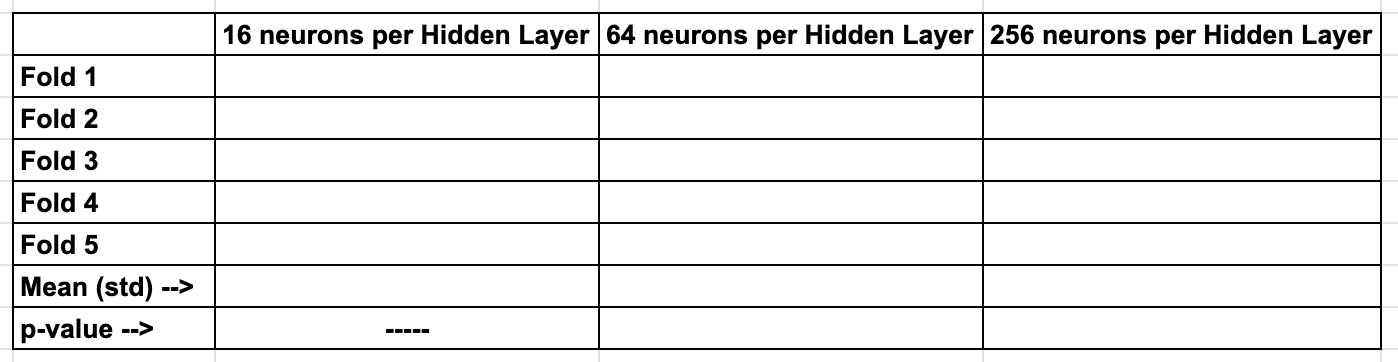

# ✅ Activity: Implementing L1 Regularization

Modify the model to accept a new hyperparameter `Lambda_L1` to implement L1 regularization. Note that `torch.optim.Adam` does not implement L1 regularization. Tip: Modify `training_step` to include the L1 norm in the loss function calculation. You don’t need to do k-fold cross-validation. Just run your implementation once to check if it works correctly.

#References

[1] https://lightning.ai/

[2] https://www.appsilon.com/post/visualize-pytorch-neural-networks